In [10]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

# The original file_path was pointing to a markdown file, not a data file.
# The 'adult-census-income' dataset typically contains 'adult.csv' as the main data file.
file_path = "adult.csv"

# Using dataset_load instead of load_dataset to address the DeprecationWarning
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/adult-census-income",
  file_path
)

100%|██████████| 450k/450k [00:00<00:00, 52.5MB/s]

Extracting zip of adult.csv...


In [11]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [13]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [14]:
num_col = df.select_dtypes(include=[np.number]).columns
print(num_col)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


In [15]:
cat_col = df.select_dtypes(include=[object]).columns
print(cat_col)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [16]:
X = df.drop("income", axis=1)
y= df["income"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col)
    ]
)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [21]:
# Remove the target column 'income' from the categorical features list
cat_features = [col for col in cat_col if col != 'income']

# Redefine preprocessor to only use valid feature columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Re-build the pipeline with the updated preprocessor
lr_pip = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Now fitting will work as 'income' is no longer expected in X_train
lr_pip.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [22]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = lr_pip.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8480

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4976
        >50K       0.72      0.58      0.64      1537

    accuracy                           0.85      6513
   macro avg       0.80      0.76      0.77      6513
weighted avg       0.84      0.85      0.84      6513



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [24]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8507600184246891

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4976
        >50K       0.71      0.62      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



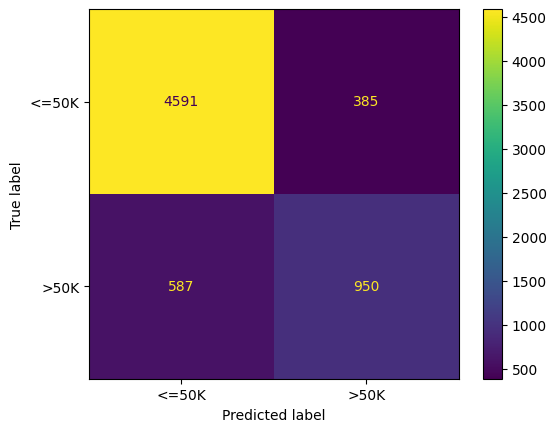

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

In [26]:
!pip install xgboost

In [27]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numerical labels (0, 1) instead of strings
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Fit using the encoded target labels
xgb_model.fit(X_train, y_train_encoded)

# Make predictions
y_pred_xgb_encoded = xgb_model.predict(X_test)
# Convert predictions back to original string labels for evaluation if needed
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

# Re-evaluating now that y_pred_xgb is defined
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8739444188545985

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4976
        >50K       0.79      0.64      0.70      1537

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513



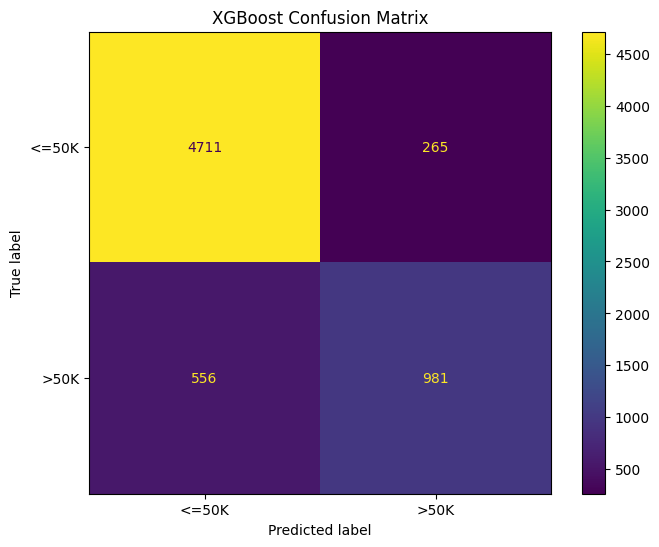

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix for XGBoost
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=le.classes_,
    ax=ax,
    cmap='viridis'
)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [30]:
import joblib

model= joblib.dump(xgb_model, "xgboost_model.pkl")
print(model)

['xgboost_model.pkl']


In [ ]:
from google.colab import _message
import json

result = _message.blocking_request(
    'get_ipynb',
    request='',
    timeout_sec=10
)

# Fix: Use json.dump to write the dictionary to the file as a string
with open('/content/adult_income.ipynb', 'w') as f:
    json.dump(result['ipynb'], f)

print("Saved successfully!")